In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/pallavin2541354/twitter-training/twitter_training.csv


In [5]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/pallavin2541354/twitter-training/twitter_training.csv",
    header=None
)

In [6]:
df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [9]:
df.columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

In [10]:
df.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [12]:
df.isnull().sum()

ID             0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [13]:
df = df.dropna()

In [14]:
df.isnull().sum()

ID           0
Entity       0
Sentiment    0
Tweet        0
dtype: int64

In [15]:
df['Sentiment'].value_counts()

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

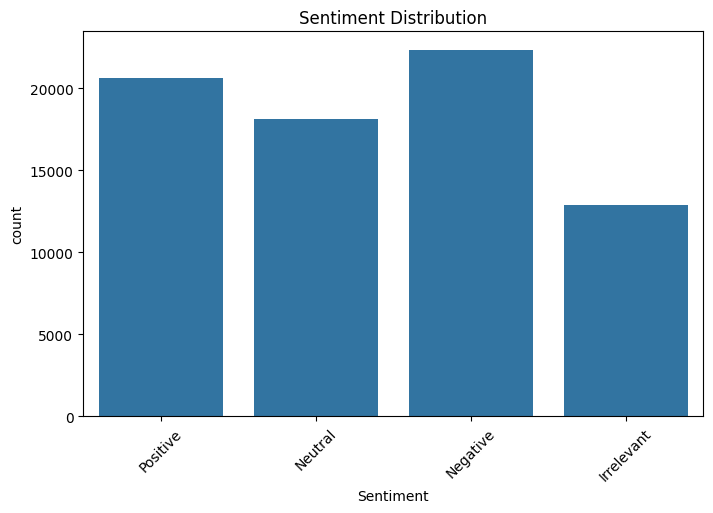

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sentiment')
plt.title("Sentiment Distribution")
plt.xticks(rotation=45)
plt.show()

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['Tweet'].astype(str))

y = df['Sentiment']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [20]:
predictions = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.7595945945945946


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

  Irrelevant       0.85      0.64      0.73      2696
    Negative       0.72      0.86      0.78      4380
     Neutral       0.83      0.66      0.74      3605
    Positive       0.73      0.82      0.77      4119

    accuracy                           0.76     14800
   macro avg       0.78      0.74      0.75     14800
weighted avg       0.77      0.76      0.76     14800



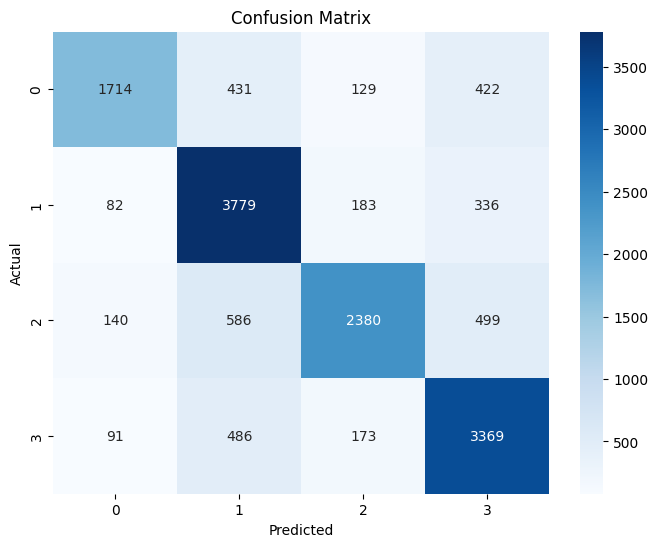

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
sample = ["I really love this product"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: Positive


In [25]:
sample = ["This is the worst service I have ever used"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: Negative


In [26]:
sample = ["The product is okay, nothing special"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

print("Prediction:", prediction[0])

Prediction: Neutral


# Conclusion

- Loaded and cleaned the Twitter sentiment dataset.
- Analyzed the distribution of sentiments using visualization.
- Converted tweet text into numerical features using CountVectorizer.
- Trained a Multinomial Naive Bayes classifier.
- Evaluated the model using accuracy, classification report, and confusion matrix.
- Successfully predicted the sentiment of new user-provided tweets.